# 5. Modeling — Churn Prediction (full-data run)

**What it does:**
1. Loads the already-processed `train` / `val` / `test` parquet files (built earlier in `4_data_prep.ipynb`).
2. Runs **time-series cross-validation** on train (expanding window over cohorts: train on the first N cohorts, validate on the next two, roll forward through all of them) to compare five models: Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost.
3. Does a model selection on the `val` split (Oct/Nov 2016).
4. Refits the winning model on train + val and evaluates **once** on `test` (the last 3 cohorts, Dec 2016 - Feb 2017).
5. Saves all tables + plots to `results/`.


## 1. Setup

In [ ]:

DATA_DIR = "../data/"

In [ ]:
try:
    import catboost
except ImportError:
    %pip install -q catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
from datetime import datetime

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, log_loss, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)


In [ ]:
#path to processed directory
PROCESSED_DIR = os.path.join(DATA_DIR, "processed/")

# Results (tables + plots) get saved here.
RESULTS_DIR = os.path.join(DATA_DIR, "results/")
os.makedirs(RESULTS_DIR, exist_ok=True)

FEATURES = [
    'avg_plan_price',
    'avg_payment_per_day',
    'days_since_first_trans',
    'days_since_last_use',
    'ratio_auto_renew',
    'total_secs_velocity',
    'num_unq_velocity',
    'last_is_auto_renew',
    'last_is_cancel',
]
TARGET = 'is_churn'
COHORT_COL = 'cohort_cutoff_date'
RANDOM_STATE = 42

MIN_TRAIN_COHORTS = 12   # cohorts required in the CV window before validating
MAX_CV_FOLDS = None      # None = run every fold (full CV). Set an int to cap folds.

# Optional: set to a fraction (e.g. 0.15) for a quick low-memory test run instead of full data.
# Leave as None for the full-data run this notebook is meant for.
SAMPLE_FRAC = None

print("Reading data from:", PROCESSED_DIR)
print("Saving results to:", RESULTS_DIR)


Reading data from: /content/drive/MyDrive/Colab Notebooks/Churn Prediction/Data/processed
Saving results to: /content/drive/MyDrive/Colab Notebooks/Churn Prediction/Data/model_results


## 2. Load Data

In [ ]:
df_train = pd.read_parquet(os.path.join(PROCESSED_DIR, "train.parquet"))
df_val = pd.read_parquet(os.path.join(PROCESSED_DIR, "val.parquet"))
df_test = pd.read_parquet(os.path.join(PROCESSED_DIR, "test.parquet"))

# Shrink dtypes to reduce memory footprint.
def shrink(df):
    for c in df.select_dtypes(include=['float64']).columns:
        df[c] = df[c].astype('float32')
    for c in df.select_dtypes(include=['int64']).columns:
        df[c] = pd.to_numeric(df[c], downcast='integer')
    return df

df_train, df_val, df_test = shrink(df_train), shrink(df_val), shrink(df_test)

if SAMPLE_FRAC is not None:
    df_train = df_train.groupby(COHORT_COL, group_keys=False).sample(
        frac=SAMPLE_FRAC, random_state=RANDOM_STATE
    )
    print(f"[TEST MODE] Sampled train down to {df_train.shape} (SAMPLE_FRAC={SAMPLE_FRAC})")

gc.collect()

print("Train:", df_train.shape, "| churn rate:", round(df_train[TARGET].mean(), 4),
      "| cohorts:", len(df_train[COHORT_COL].unique()))
print("Val:  ", df_val.shape, "| churn rate:", round(df_val[TARGET].mean(), 4),
      "| cohorts:", len(df_val[COHORT_COL].unique()))
print("Test: ", df_test.shape, "| churn rate:", round(df_test[TARGET].mean(), 4),
      "| cohorts:", len(df_test[COHORT_COL].unique()))


Train: (12543036, 15) | churn rate: 0.0796 | cohorts: 20
Val:   (1708636, 15) | churn rate: 0.0652 | cohorts: 2
Test:  (2606258, 15) | churn rate: 0.0551 | cohorts: 3


In [ ]:
df_train.groupby(COHORT_COL)[TARGET].mean()

,is_churn
cohort_cutoff_date,
2015-02-01,0.036477
2015-03-01,0.043541
2015-04-01,0.192821
2015-05-01,0.059126
2015-06-01,0.065444
2015-07-01,0.056044
2015-08-01,0.062627
2015-09-01,0.105126
2015-10-01,0.086655


In [ ]:
df_val.groupby(COHORT_COL)[TARGET].mean()

,is_churn
cohort_cutoff_date,
2016-10-01,0.038311
2016-11-01,0.090468


In [ ]:
df_test.groupby(COHORT_COL)[TARGET].mean()

,is_churn
cohort_cutoff_date,
2016-12-01,0.080584
2017-01-01,0.044934
2017-02-01,0.039446


## 2a. Feature Visualization

In [ ]:
df_all = pd.concat(
    [df_train, df_val, df_test],
    axis=0,
    ignore_index=True
)

df_sample = (
    df_all.groupby(TARGET, group_keys=False)
    .sample(
        n=1000000,
        random_state=42
    )
)

df_plot = df_sample.copy()

# continuous features
continuous_features = [
    'avg_plan_price',
    'avg_payment_per_day',
    'days_since_first_trans',
    'days_since_last_use',
    'ratio_auto_renew',
    'total_secs_velocity',
    'num_unq_velocity'
]


# standardize continuous features only
scaler = StandardScaler()

df_plot[continuous_features] = scaler.fit_transform(
    df_plot[continuous_features]
)

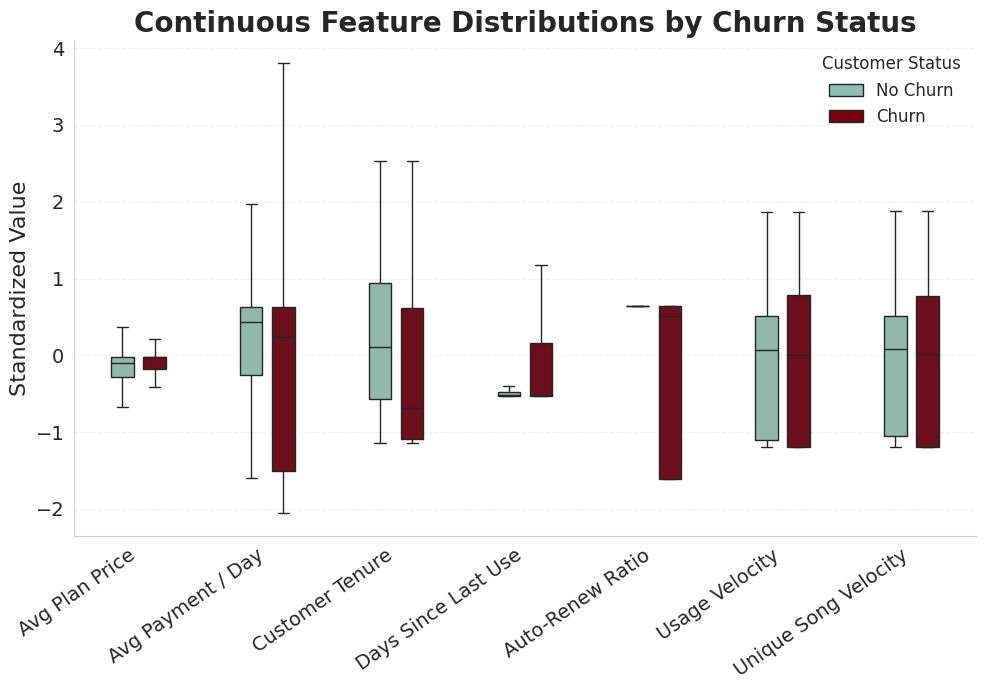

In [ ]:
# visualize continous features

long_df = df_plot[
    continuous_features + [TARGET]
].melt(
    id_vars=[TARGET],
    value_vars=continuous_features,
    var_name="Feature",
    value_name="Value"
)

cont_feature_names = {
    "avg_plan_price": "Avg Plan Price",
    "avg_payment_per_day": "Avg Payment / Day",
    "days_since_first_trans": "Customer Tenure",
    "days_since_last_use": "Days Since Last Use",
    "ratio_auto_renew": "Auto-Renew Ratio",
    "total_secs_velocity": "Usage Velocity",
    "num_unq_velocity": "Unique Song Velocity"
}

long_df["Feature"] = long_df["Feature"].replace(cont_feature_names)

plt.figure(figsize=(10, 7))

ax = sns.boxplot(
    data=long_df,
    x="Feature",
    y="Value",
    hue=TARGET,
    hue_order=[0, 1],
    palette={
        0: "#8BBFAF",
        1: "#7A0010"
    },
    width=0.5,
    gap=0.3,
    showfliers=False
)

plt.title(
    "Continuous Feature Distributions by Churn Status",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Standardized Value", fontsize=16)

plt.xticks(
    rotation=35,
    ha="right",
    fontsize=14
)

plt.yticks(fontsize=14)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles, labels = ax.get_legend_handles_labels()

handles[0].set_facecolor("#8BBFAF")
handles[1].set_facecolor("#7A0010")

plt.legend(
    handles,
    ["No Churn", "Churn"],
    title="Customer Status",
    frameon=False,
    loc="upper right",
    fontsize=12,
    title_fontsize=12
)

plt.tight_layout()
plt.show()

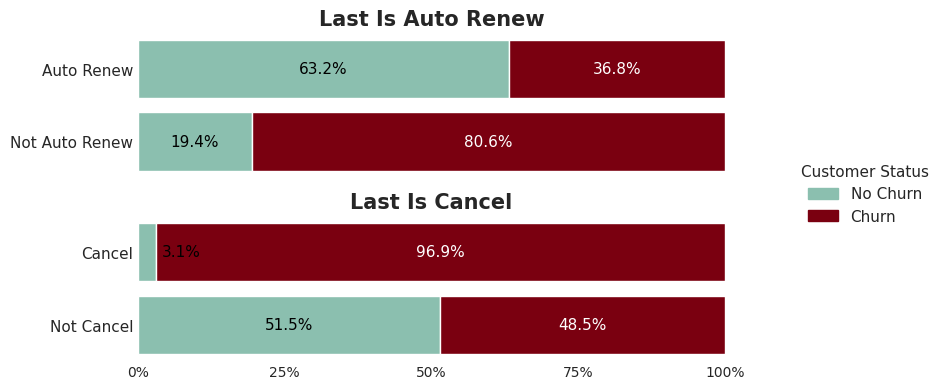

In [ ]:
# Visualize binary features

binary_features = [
    'last_is_auto_renew',
    'last_is_cancel'
]

colors = {
    0: "#8BBFAF",   # No Churn
    1: "#7A0010"    # Churn
}

bin_feature_names = {
    "last_is_auto_renew": ["Not Auto Renew", "Auto Renew"],
    "last_is_cancel": ["Not Cancel", "Cancel"]
}

fig, axes = plt.subplots(
    nrows=len(binary_features),
    figsize=(9, 4),
    sharex=True
)


for ax, feature in zip(axes, binary_features):

    count_df = (
        df_sample
        .groupby([feature, TARGET])
        .size()
        .reset_index(name="Count")
    )

    count_df["Proportion"] = (
        count_df["Count"]
        /
        count_df.groupby(feature)["Count"].transform("sum")
    )

    plot_df = count_df.pivot(
        index=feature,
        columns=TARGET,
        values="Proportion"
    )

    plot_df = (
        plot_df
        .reindex(columns=[0, 1])
        .fillna(0)
    )

    plot_df = plot_df.div(
        plot_df.sum(axis=1),
        axis=0
    )

    y_labels = bin_feature_names[feature]
    left = [0] * len(plot_df)

    for churn_status in [0, 1]:

        values = plot_df[churn_status].values


        ax.barh(
            y_labels,
            values,
            left=left,
            color=colors[churn_status],
            label="No Churn" if churn_status == 0 else "Churn"
        )

        # Percentage labels
        for i, v in enumerate(values):
            if v >= 0.05:

                # green -> black
                # red -> white
                text_color = (
                    "black"
                    if churn_status == 0
                    else "white"
                )

                ax.text(
                    left[i] + v / 2,
                    i,
                    f"{v*100:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=11,
                    color=text_color
                )

            elif v > 0:
                ax.text(
                    left[i] + v + 0.01,
                    i,
                    f"{v*100:.1f}%",
                    ha="left",
                    va="center",
                    fontsize=11,
                    color="black"
                )


        left = [
            left[i] + values[i]
            for i in range(len(left))
        ]

    ax.set_title(
        feature.replace("_", " ").title(),
        fontsize=15,
        fontweight="bold"
    )


    ax.set_xlim(0, 1)
    ax.set_xticks(
        [0, 0.25, 0.5, 0.75, 1]
    )

    ax.set_xticklabels(
        ["0%", "25%", "50%", "75%", "100%"],
        fontsize=10
    )
    ax.set_xlabel("")

    ax.tick_params(
        axis="y",
        labelsize=11,
        length=0
    )

    ax.tick_params(
        axis="x",
        length=0
    )

    # Remove grid and borders
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[0]),
    plt.Rectangle((0, 0), 1, 1, color=colors[1])
]


fig.legend(
    handles,
    ["No Churn", "Churn"],
    title="Customer Status",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5),
    fontsize=11,
    title_fontsize=11
)


plt.tight_layout(
    rect=[0, 0, 0.85, 1]
)

plt.show()

## 2b. Fix a potential leak in the `days_since_last_use` sentinel

In `4_data_prep`, missing `days_since_last_use` values were imputed with a sentinel computed as `(max over the WHOLE train set) + 1` Because that max was taken over all train cohorts, the value baked into every split (including val/test) encodes information from cohorts a given fold shouldn't have seen yet. It's a mild but real leak.

We fix it here using the `days_since_last_use_missing` flag column that `4_data_prep` saved (it marks exactly which rows were imputed):

1. Recover train's *real* (non-imputed) max from the rows where the flag is 0.
2. Recompute the sentinel from **train's real max only**.
3. Overwrite the imputed cells (flag == 1) in train/val/test with that train-only sentinel.

After this the sentinel depends only on train, so it no longer leaks future/holdout info for the train/test split. (A tiny residual leak remains *within* the CV folds; the fully-clean fix is per-fold imputation inside a pipeline. Since selection is on the untouched val set and this isn't a top feature, the impact is negligible.)

In [ ]:
FLAG_COL = 'days_since_last_use_missing'
assert FLAG_COL in df_train.columns, f"{FLAG_COL} not found — needed to fix the sentinel leak."

# 1. Train's real max = max over rows that were NOT imputed (flag == 0).
train_real_max = df_train.loc[df_train[FLAG_COL] == 0, 'days_since_last_use'].max()
clean_sentinel = train_real_max + 1
print(f"Train-only real max days_since_last_use: {train_real_max:.1f}")
print(f"Clean sentinel (train max + 1): {clean_sentinel:.1f}")

# 2. Overwrite imputed cells (flag == 1) in every split with the train-only sentinel.
for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    n_imputed = int((df[FLAG_COL] == 1).sum())
    df.loc[df[FLAG_COL] == 1, 'days_since_last_use'] = clean_sentinel
    print(f"  {name}: overwrote {n_imputed:,} imputed rows with the clean sentinel")

gc.collect()

Train-only real max days_since_last_use: 608.0
Clean sentinel (train max + 1): 609.0
  train: overwrote 1,917,437 imputed rows with the clean sentinel
  val: overwrote 239,016 imputed rows with the clean sentinel
  test: overwrote 357,731 imputed rows with the clean sentinel


0

## 3. Time-Series Cross-Validation Setup

Expanding window over cohorts: for each fold, train on all cohorts up to a point and validate on the next one, rolling forward. A random K-fold would leak future cohorts into folds that validate earlier ones, so we use this time-ordered scheme instead.


In [ ]:
def expanding_window_cohort_splits(cohort_dates, min_train_cohorts=MIN_TRAIN_COHORTS, max_folds=MAX_CV_FOLDS):
    sorted_cohorts = sorted(cohort_dates)
    all_folds = [
        (sorted_cohorts[:i], sorted_cohorts[i:i+2])
        for i in range(min_train_cohorts, len(sorted_cohorts), 2)
    ]
    if max_folds is not None and len(all_folds) > max_folds:
        idx = sorted(set(np.linspace(0, len(all_folds) - 1, max_folds).round().astype(int)))
        all_folds = [all_folds[i] for i in idx]
    return all_folds


cv_folds = expanding_window_cohort_splits(df_train[COHORT_COL].unique())
print(f"Number of CV folds: {len(cv_folds)}")
for train_cohorts, val_cohorts in cv_folds:
    print(f"  train {min(train_cohorts).date()}..{max(train_cohorts).date()} "
          f"({len(train_cohorts)} cohorts) -> validate {min(val_cohorts).date()}..{max(val_cohorts).date()}")


Number of CV folds: 4
  train 2015-02-01..2016-01-01 (12 cohorts) -> validate 2016-02-01..2016-03-01
  train 2015-02-01..2016-03-01 (14 cohorts) -> validate 2016-04-01..2016-05-01
  train 2015-02-01..2016-05-01 (16 cohorts) -> validate 2016-06-01..2016-07-01
  train 2015-02-01..2016-07-01 (18 cohorts) -> validate 2016-08-01..2016-09-01


In [ ]:
def evaluate_folds(model_fn, frame, cv_folds, features, target):
    results = []
    for train_cohorts, val_cohorts in cv_folds:
        tr = frame[frame[COHORT_COL].isin(train_cohorts)]
        va = frame[frame[COHORT_COL].isin(val_cohorts)]

        X_tr, y_tr = tr[features], tr[target]
        X_va, y_va = va[features], va[target]

        model = model_fn()
        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_va)[:, 1]

        results.append({
            'val_cohort': f"{min(val_cohorts).date()}..{max(val_cohorts).date()}",
            'roc_auc': roc_auc_score(y_va, probs),
            'log_loss': log_loss(y_va, probs),
            'pr_auc': average_precision_score(y_va, probs),
        })
        print(f"  {min(val_cohorts).date()}..{max(val_cohorts).date()}: "
              f"ROC-AUC={results[-1]['roc_auc']:.4f}  "
              f"LogLoss={results[-1]['log_loss']:.4f}  "
              f"PR-AUC={results[-1]['pr_auc']:.4f}")

        del tr, va, X_tr, y_tr, X_va, y_va, model, probs
        gc.collect()

    return pd.DataFrame(results)


## 4. Candidate Models

In [ ]:
def make_logreg():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=50,
        random_state=RANDOM_STATE, n_jobs=-1,
    )

def make_xgb():
    return xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', tree_method='hist',
        random_state=RANDOM_STATE, n_jobs=-1,
    )

def make_lgbm():
    return lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    )

def make_catboost():
    return CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        random_state=RANDOM_STATE, verbose=False,
    )

all_model_fns = {
    'LogReg': make_logreg,
    'RandomForest': make_rf,
    'XGBoost': make_xgb,
    'LightGBM': make_lgbm,
    'CatBoost': make_catboost,
}

# NOTE: class balancing removed from all models.
# We now leave all five unweighted so the methodology is consistent across models. Since we select
# on PR-AUC (a ranking metric, fairly insensitive to weighting) and use the predicted probabilities
# for SHAP/explanation, unweighted models give better-calibrated probabilities and lower log loss.

## 5. Run Time-Series CV for All Models

In [ ]:
cv_results = {}
for name, fn in all_model_fns.items():
    print(f"[{name}]")
    cv_results[name] = evaluate_folds(fn, df_train, cv_folds, FEATURES, TARGET)
    gc.collect()
    print()


[LogReg]
  2016-02-01..2016-03-01: ROC-AUC=0.6458  LogLoss=0.4700  PR-AUC=0.3663
  2016-04-01..2016-05-01: ROC-AUC=0.8126  LogLoss=0.1965  PR-AUC=0.4276
  2016-06-01..2016-07-01: ROC-AUC=0.8622  LogLoss=0.1563  PR-AUC=0.4868
  2016-08-01..2016-09-01: ROC-AUC=0.8781  LogLoss=0.1414  PR-AUC=0.5523

[RandomForest]
  2016-02-01..2016-03-01: ROC-AUC=0.8437  LogLoss=0.3012  PR-AUC=0.5629
  2016-04-01..2016-05-01: ROC-AUC=0.9003  LogLoss=0.1552  PR-AUC=0.5796
  2016-06-01..2016-07-01: ROC-AUC=0.9165  LogLoss=0.1277  PR-AUC=0.5709
  2016-08-01..2016-09-01: ROC-AUC=0.9186  LogLoss=0.1191  PR-AUC=0.5930

[XGBoost]
  2016-02-01..2016-03-01: ROC-AUC=0.7737  LogLoss=0.3591  PR-AUC=0.5109
  2016-04-01..2016-05-01: ROC-AUC=0.9047  LogLoss=0.1532  PR-AUC=0.5648
  2016-06-01..2016-07-01: ROC-AUC=0.9215  LogLoss=0.1245  PR-AUC=0.5657
  2016-08-01..2016-09-01: ROC-AUC=0.9208  LogLoss=0.1204  PR-AUC=0.5806

[LightGBM]
  2016-02-01..2016-03-01: ROC-AUC=0.8187  LogLoss=0.3515  PR-AUC=0.5269
  2016-04-01..20

In [ ]:
cv_comparison = pd.DataFrame({
    name: res[['roc_auc', 'log_loss', 'pr_auc']].mean()
    for name, res in cv_results.items()
}).T.sort_values('pr_auc', ascending=False)

# Save per-fold results and the summary comparison.
for name, res in cv_results.items():
    res.to_csv(os.path.join(RESULTS_DIR, f"cv_folds_{name}.csv"), index=False)
cv_comparison.to_csv(os.path.join(RESULTS_DIR, "cv_comparison.csv"))

print("Saved CV results to", RESULTS_DIR)
cv_comparison

Saved CV results to csv_files/model_results


,roc_auc,log_loss,pr_auc
RandomForest,0.894769,0.175804,0.576599
CatBoost,0.898883,0.187079,0.566358
XGBoost,0.880165,0.189306,0.555496
LightGBM,0.894000,0.186863,0.553290
LogReg,0.799694,0.241053,0.458259


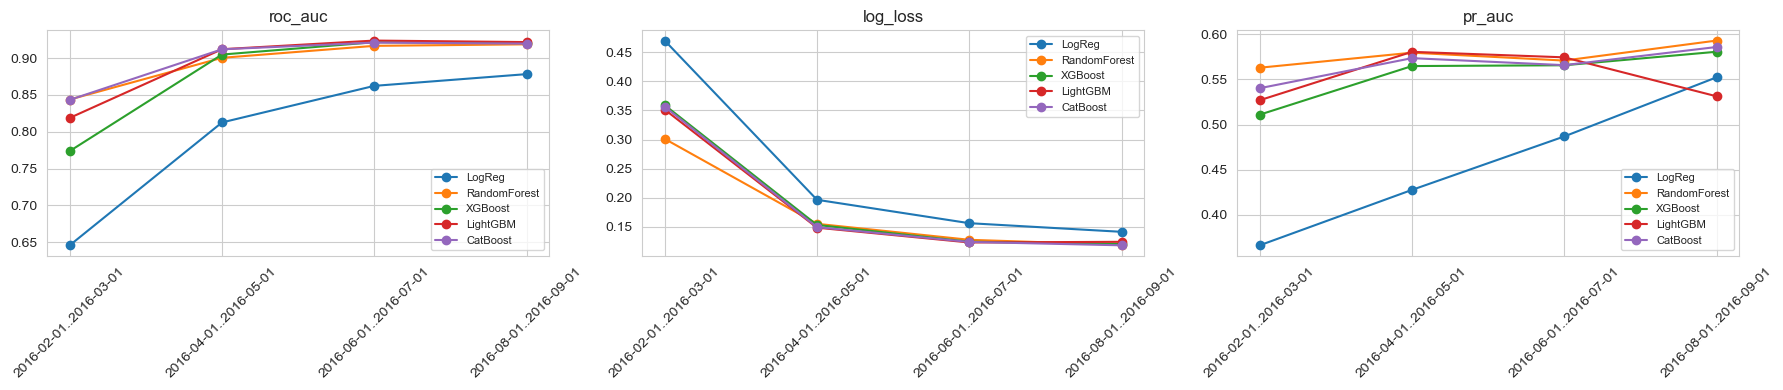

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, metric in zip(axes, ['roc_auc', 'log_loss', 'pr_auc']):
    for name, res in cv_results.items():
        ax.plot(res['val_cohort'], res[metric], marker='o', label=name)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cv_metrics_by_cohort.png"), dpi=120, bbox_inches='tight')
plt.show()


## 6. Model Selection on the Validation Set

**This is where we pick the winner.** Each model is trained on the sampled train set and scored on the fixed validation cohorts (Oct/Nov 2016). It's a clean split that sits in time *after* train, mimicking real deployment (train on history, predict the next period). We select the model with the best validation PR-AUC.

The time-series CV above is used as a **robustness diagnostic**, not for selection: it tells us whether a model is stable across many time points. Ideally the val winner also looks stable in CV; if the val winner swings wildly across CV folds, that's a flag to prefer a steadier model.


In [ ]:
val_rows = []
for name, fn in all_model_fns.items():
    model = fn()
    model.fit(df_train[FEATURES], df_train[TARGET])
    probs = model.predict_proba(df_val[FEATURES])[:, 1]
    val_rows.append({
        'model': name,
        'roc_auc': roc_auc_score(df_val[TARGET], probs),
        'log_loss': log_loss(df_val[TARGET], probs),
        'pr_auc': average_precision_score(df_val[TARGET], probs),
    })
    del model, probs
    gc.collect()

val_comparison = pd.DataFrame(val_rows).set_index('model').sort_values('pr_auc', ascending=False)
val_comparison


,roc_auc,log_loss,pr_auc
model,,,
XGBoost,0.940156,0.108355,0.758815
CatBoost,0.937938,0.108914,0.758030
RandomForest,0.937746,0.110285,0.757586
LightGBM,0.940053,0.108978,0.756271
LogReg,0.904466,0.134831,0.703164


## 7. Final Model: Refit on Train + Val, Evaluate Once on Test

Take the **validation-selected** winner, refit it on sampled-train + val combined, and evaluate exactly once on `test` (the last 3 cohorts, Dec 2016 – Feb 2017), untouched until now.


### 7a. Hyperparameter tuning for the winning model (Optuna, validation-based)

XGBoost won on validation, so we tune *its* hyperparameters before the final test evaluation. **Important:** tuning uses the **validation set as the judge** (we maximize val PR-AUC). The **test set is never used for tuning**. it's touched once, at the very end, for the final number. Using test to pick hyperparameters would leak and inflate the result.

Optuna uses Bayesian (TPE) optimization, learning from past trials to propose promising params, so it finds good settings in relatively few trials (20 here).

In [ ]:
best_model_name = 'XGBoost'

import json

try:
    import optuna
except ImportError:
    %pip install -q optuna
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNE_MODEL = 'XGBoost'
N_TRIALS = 20

def xgb_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 300, 900, step=100),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
        gamma=trial.suggest_float('gamma', 0.0, 5.0),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    )
    model = xgb.XGBClassifier(
        **params, eval_metric='logloss', tree_method='hist',
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    # Judge = validation set (NOT test). Train on train, score val PR-AUC.
    model.fit(df_train[FEATURES], df_train[TARGET])
    probs = model.predict_proba(df_val[FEATURES])[:, 1]
    return average_precision_score(df_val[TARGET], probs)


if best_model_name == TUNE_MODEL:
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_params = study.best_params
    print(f"\nBest val PR-AUC from tuning: {study.best_value:.4f}")
    print("Best params:", json.dumps(best_params, indent=2))

    def make_tuned_final():
        return xgb.XGBClassifier(
            **best_params, eval_metric='logloss', tree_method='hist',
            random_state=RANDOM_STATE, n_jobs=-1,
        )
else:
    print(f"Winner is {best_model_name}, not {TUNE_MODEL}; skipping tuning, using default model.")
    best_params = None
    make_tuned_final = all_model_fns[best_model_name]

Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/20 [00:00<?, ?it/s]


Best val PR-AUC from tuning: 0.7600
Best params: {
  "n_estimators": 700,
  "learning_rate": 0.013395241795324832,
  "max_depth": 10,
  "subsample": 0.6274727503960831,
  "colsample_bytree": 0.8098959246574363,
  "min_child_weight": 7,
  "gamma": 4.584018323017892,
  "reg_lambda": 0.22811287575472036
}


In [ ]:
print(f"Winner (selected on val PR-AUC): {best_model_name}")

df_train_val = pd.concat([df_train, df_val], ignore_index=True)

# Use the Optuna-tuned XGBoost from 7a if available; otherwise the default winner model.
final_model = make_tuned_final()
final_model.fit(df_train_val[FEATURES], df_train_val[TARGET])

test_probs = final_model.predict_proba(df_test[FEATURES])[:, 1]

print("\nFinal test performance (all held-out cohorts):")
print("  ROC-AUC:", round(roc_auc_score(df_test[TARGET], test_probs), 4))
print("  Log Loss:", round(log_loss(df_test[TARGET], test_probs), 4))
print("  PR-AUC:", round(average_precision_score(df_test[TARGET], test_probs), 4))

Winner (selected on val PR-AUC): XGBoost

Final test performance (all held-out cohorts):
  ROC-AUC: 0.8303
  Log Loss: 0.1479
  PR-AUC: 0.542


In [ ]:
rows = []
for cohort in sorted(df_test[COHORT_COL].unique()):
    m = df_test[COHORT_COL] == cohort
    rows.append({
        'cohort': pd.Timestamp(cohort).date(),
        'n': int(m.sum()),
        'roc_auc': roc_auc_score(df_test.loc[m, TARGET], test_probs[m.values]),
        'log_loss': log_loss(df_test.loc[m, TARGET], test_probs[m.values]),
        'pr_auc': average_precision_score(df_test.loc[m, TARGET], test_probs[m.values]),
    })
pd.DataFrame(rows)


,cohort,n,roc_auc,log_loss,pr_auc
0,2016-12-01,874645,0.788336,0.204116,0.623725
1,2017-01-01,860187,0.879429,0.120503,0.475328
2,2017-02-01,871426,0.858485,0.118607,0.379336


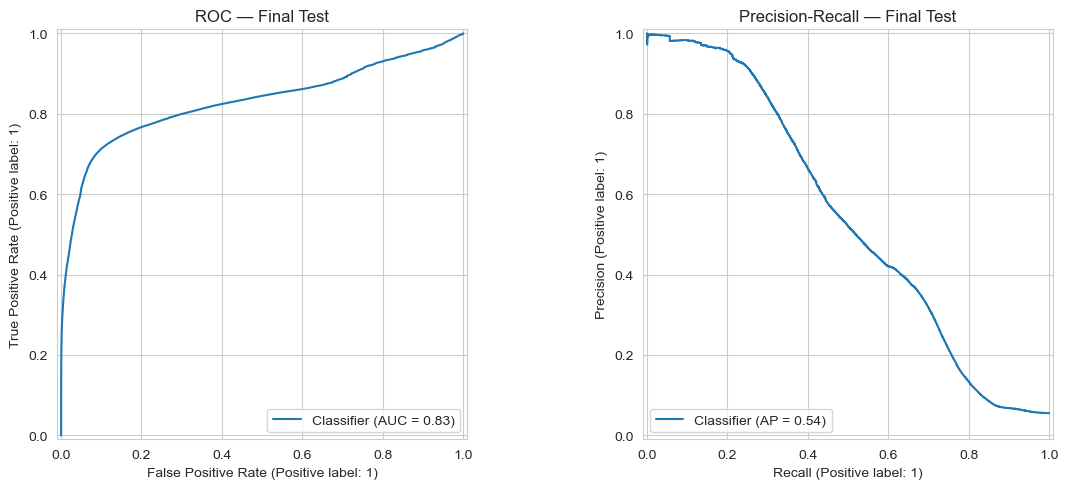

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(df_test[TARGET], test_probs, ax=ax[0])
ax[0].set_title("ROC — Final Test")
PrecisionRecallDisplay.from_predictions(df_test[TARGET], test_probs, ax=ax[1])
ax[1].set_title("Precision-Recall — Final Test")
plt.tight_layout()
plt.show()


## 8. Feature Importance

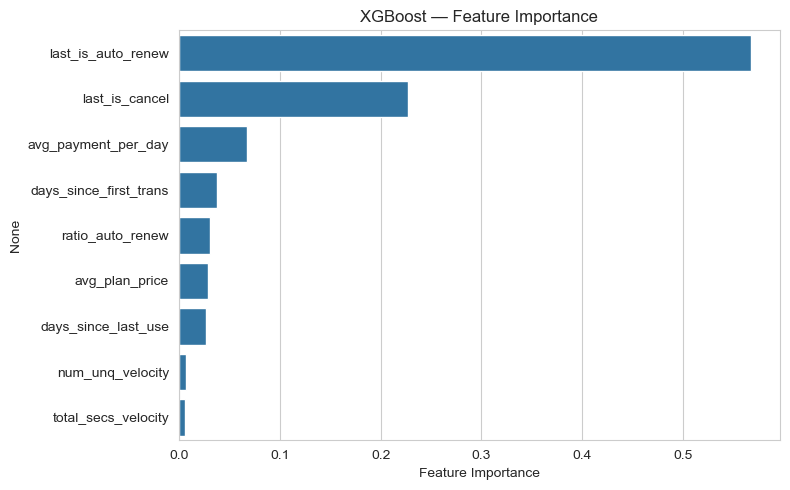

last_is_auto_renew        0.567477
last_is_cancel            0.226860
avg_payment_per_day       0.067268
days_since_first_trans    0.037624
ratio_auto_renew          0.031056
avg_plan_price            0.029105
days_since_last_use       0.026723
num_unq_velocity          0.007444
total_secs_velocity       0.006443
dtype: float32

In [ ]:
if best_model_name == 'LogReg':
    coefs = final_model.named_steps['clf'].coef_[0]
    importances = pd.Series(np.abs(coefs), index=FEATURES).sort_values(ascending=False)
    label = "|Standardized Coefficient|"
else:
    importances = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
    label = "Feature Importance"

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title(f"{best_model_name} — {label}")
plt.xlabel(label)
plt.tight_layout()
plt.show()

importances


## 9. SHAP Analysis (winning model)

Feature importance above tells us *which* features matter; SHAP tells us **which direction** each feature pushes a prediction and **how much**, per row. Great for the slides / final story.

- SHAP is computed on a **random subsample** of the test set  (`SHAP_SAMPLE_N` rows) — SHAP evaluates every row individually, so a few thousand representative rows give stable plots without the cost of the full set.
- `TreeExplainer` is used for tree models (fast, exact). If the CV winner is `LogReg`, we fall back to a linear explainer so this section still runs.


In [ ]:
try:
    import shap
except ImportError:
    %pip install -q shap
    import shap

RESULTS_DIR = os.path.join(DATA_DIR, "model_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

SHAP_SAMPLE_N = 20000  # rows to compute SHAP on; lower if it's slow, raise for smoother plots

In [ ]:
shap_sample = df_test[FEATURES].sample(
    n=min(SHAP_SAMPLE_N, len(df_test)), random_state=RANDOM_STATE
).reset_index(drop=True)

tree_models = {'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost'}

if best_model_name in tree_models:
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(shap_sample)
    # Normalize to a 2D (n_samples, n_features) array across SHAP/model versions:
    if isinstance(shap_values, list):
        shap_values = shap_values[1]           # older API: [class0, class1] -> positive class
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]     # newer API: (n, features, classes) -> positive class
else:
    pre = Pipeline(final_model.steps[:-1])
    clf = final_model.steps[-1][1]
    shap_sample = pd.DataFrame(pre.transform(shap_sample), columns=FEATURES)
    explainer = shap.LinearExplainer(clf, shap_sample)
    shap_values = np.asarray(explainer.shap_values(shap_sample))

print(f"SHAP values computed for {best_model_name}: shape {shap_values.shape} on {len(shap_sample)} rows.")

SHAP values computed for XGBoost: shape (20000, 9) on 20000 rows.


### 9a. SHAP Summary Plot (beeswarm) — direction + magnitude per feature

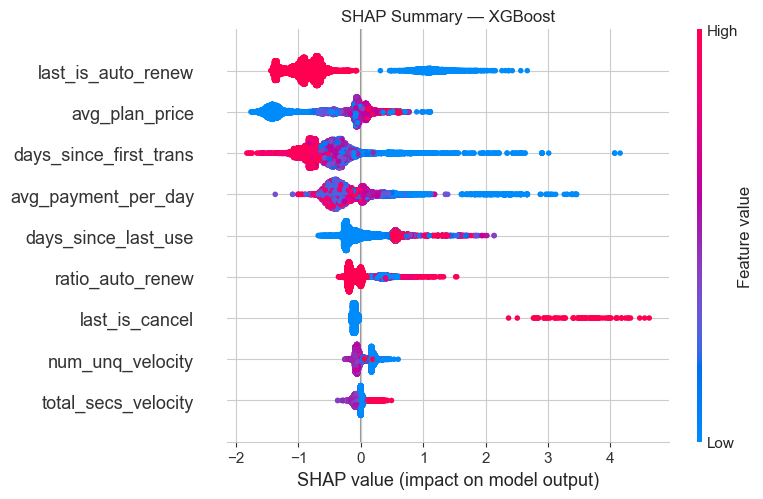

In [ ]:
plt.figure()
shap.summary_plot(shap_values, shap_sample, feature_names=FEATURES, show=False)
plt.title(f"SHAP Summary — {best_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "shap_summary_beeswarm.png"), dpi=120, bbox_inches='tight')
plt.show()


### 9b. SHAP Bar Plot — mean absolute impact (importance ranking)

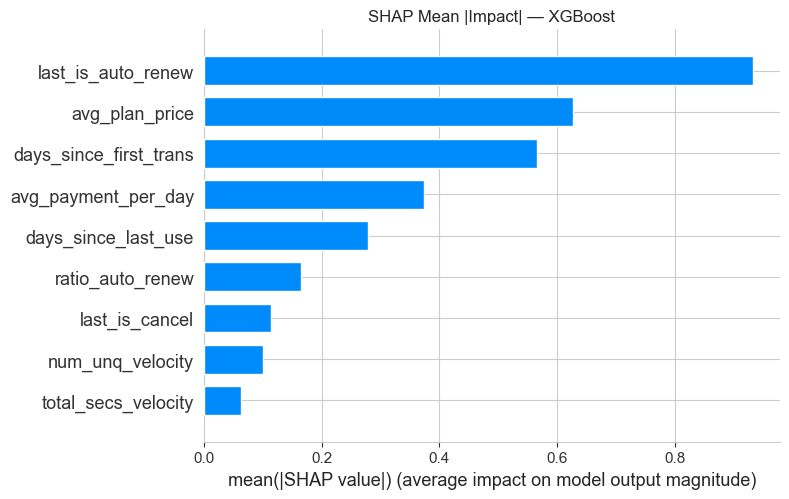

last_is_auto_renew        0.931641
avg_plan_price            0.626010
days_since_first_trans    0.566460
avg_payment_per_day       0.372987
days_since_last_use       0.278942
ratio_auto_renew          0.164690
last_is_cancel            0.114622
num_unq_velocity          0.099679
total_secs_velocity       0.063067
dtype: float32

In [ ]:
plt.figure()
shap.summary_plot(shap_values, shap_sample, feature_names=FEATURES, plot_type='bar', show=False)
plt.title(f"SHAP Mean |Impact| — {best_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "shap_bar.png"), dpi=120, bbox_inches='tight')
plt.show()

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES).sort_values(ascending=False)
mean_abs_shap.to_csv(os.path.join(RESULTS_DIR, "shap_mean_abs.csv"), header=['mean_abs_shap'])
mean_abs_shap

### 9c. SHAP Dependence Plots - how a single feature's value maps to its effect

One plot per top feature (by mean |SHAP|): how the feature's value relates to how much it pushed churn probability up or down across the sampled rows.

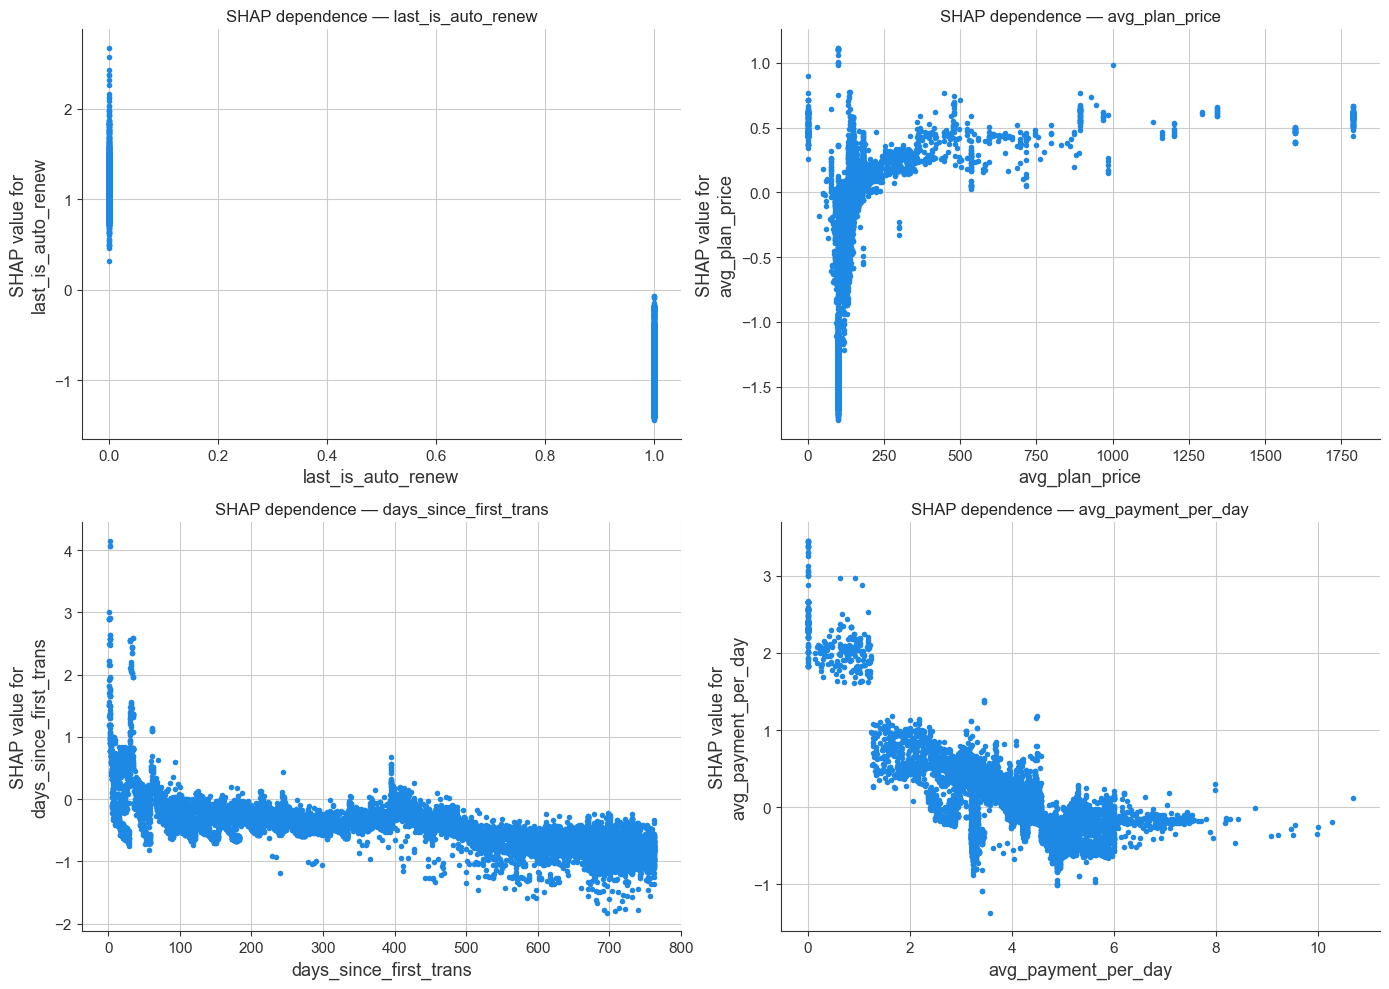

In [ ]:
top_features = mean_abs_shap.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.ravel(), top_features):
    shap.dependence_plot(
        feat, shap_values, shap_sample, feature_names=FEATURES,
        interaction_index=None, ax=ax, show=False
    )
    ax.set_title(f"SHAP dependence — {feat}")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "shap_dependence_top4.png"), dpi=120, bbox_inches='tight')
plt.show()

## 10. Save Models & Metadata

We save two sets of models to results/ so later notebooks don't have to retrain:

1. **Winner model, trained on train+val** (`final_model.pkl`) — the single best model used for the final test evaluation and for the LLM explanation notebook (`7_llm_*`), which only needs the one winning model.
2. **All 5 models, each trained on train only** (`models_train_only/`) — for the ensemble notebook (`6_ensemble`), which combines multiple models. Trained on train (not train+val) so the ensemble can fairly combine them on val/test without those splits having been seen in training.

In [ ]:
import joblib
import json

# --- (1) Winner model, trained on train+val (for final test + the LLM explanation notebook) ---
joblib.dump(final_model, os.path.join(RESULTS_DIR, "final_model.pkl"))

with open(os.path.join(RESULTS_DIR, "model_meta.json"), "w") as f:
    json.dump({
        "best_model_name": best_model_name,
        "features": FEATURES,
        "target": TARGET,
    }, f, indent=2)

print("Saved winner (train+val):")
print("  -", os.path.join(RESULTS_DIR, "final_model.pkl"))
print("  -", os.path.join(RESULTS_DIR, "model_meta.json"))
print(f"  Best model: {best_model_name}")

Saved winner (train+val):
  - csv_files/model_results\final_model.pkl
  - csv_files/model_results\model_meta.json
  Best model: XGBoost


In [ ]:
# --- (2) All 5 models, each trained on TRAIN ONLY (for the ensemble notebook) ---
TRAIN_MODELS_DIR = os.path.join(RESULTS_DIR, "models_train_only")
os.makedirs(TRAIN_MODELS_DIR, exist_ok=True)

for name, make_fn in all_model_fns.items():
    m = make_fn()
    m.fit(df_train[FEATURES], df_train[TARGET])
    joblib.dump(m, os.path.join(TRAIN_MODELS_DIR, f"{name}.pkl"))
    print(f"  saved {name}.pkl (trained on train only)")
    del m
    gc.collect()

with open(os.path.join(TRAIN_MODELS_DIR, "models_meta.json"), "w") as f:
    json.dump({
        "models": list(all_model_fns.keys()),
        "features": FEATURES,
        "target": TARGET,
        "trained_on": "train only (not train+val)",
    }, f, indent=2)

print("\nSaved 5 train-only models to", TRAIN_MODELS_DIR)

  saved LogReg.pkl (trained on train only)
  saved RandomForest.pkl (trained on train only)
  saved XGBoost.pkl (trained on train only)
  saved LightGBM.pkl (trained on train only)
  saved CatBoost.pkl (trained on train only)

Saved 5 train-only models to csv_files/model_results\models_train_only
